<a href="https://colab.research.google.com/github/bru02/epstein/blob/main/notebooks/corpus_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Corpus analysis

Run in Colab or locally. The first cell installs project dependencies when running on Colab.

In [1]:
is_colab = "google.colab" in str(get_ipython())
if is_colab:
    get_ipython().system("uv pip install --system 'epstein @ git+https://github.com/bru02/epstein'")

Using Python 3.12.13 environment at: /usr
Resolved 94 packages in 1.82s
Prepared 30 packages in 1m 17s
Uninstalled 12 packages in 751ms
Installed 30 packages in 402ms
 - beautifulsoup4==4.13.5
 + beautifulsoup4==4.14.3
 - cuda-bindings==12.9.4
 + cuda-bindings==13.2.0
 - cuda-toolkit==12.8.1
 + cuda-toolkit==13.0.2
 - duckdb==1.3.2
 + duckdb==1.5.2
 + epstein==0.1.0 (from git+https://github.com/bru02/epstein@6e0d3a427cd47b1f15556b37b371567dbbdb130f)
 + fasttext-numpy2==0.10.4
 - matplotlib==3.10.0
 + matplotlib==3.10.8
 - nltk==3.9.1
 + nltk==3.9.4
 + nvidia-cublas==13.1.0.3
 + nvidia-cuda-cupti==13.0.85
 + nvidia-cuda-nvrtc==13.0.88
 + nvidia-cuda-runtime==13.0.96
 + nvidia-cudnn-cu13==9.19.0.56
 + nvidia-cufft==12.0.0.61
 + nvidia-cufile==1.15.1.6
 + nvidia-curand==10.4.0.35
 + nvidia-cusolver==12.0.4.66
 + nvidia-cusparse==12.6.3.3
 + nvidia-cusparselt-cu13==0.8.0
 + nvidia-nccl-cu13==2.28.9
 + nvidia-nvjitlink==13.0.88
 + nvidia-nvshmem-cu13==3.4.5
 + nvidia-nvtx==13.0.85
 - polars

In [2]:
%matplotlib inline
from collections import Counter
from functools import lru_cache
import json
from pathlib import Path
import re
from time import perf_counter

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
from nltk.stem.snowball import SnowballStemmer
import polars as pl
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS, TfidfVectorizer

Path("outputs").mkdir(exist_ok=True)
started_at = perf_counter()
last_at = started_at
token_pattern = re.compile(r"\b[a-zA-Z][a-zA-Z']{2,}\b")
sentence_pattern = re.compile(r"[.!?]+")
stop_words = set(ENGLISH_STOP_WORDS)
stemmer = SnowballStemmer("english")

# Set to None for the full corpus. Use a smaller number while iterating.
sample_documents = None
sample_seed = 7
use_stemming = True
vectorizer_min_df = 5
vectorizer_max_df = 0.8
vectorizer_ngram_range = (1, 3)
vectorizer_max_features = None


def log(label):
    global last_at
    now = perf_counter()
    print(f"[analysis] {label}: phase={now - last_at:.2f}s total={now - started_at:.2f}s", flush=True)
    last_at = now


def write_frame(frame, path):
    frame.write_csv(Path("outputs") / path)
    print(f"[analysis] wrote outputs/{path}", flush=True)


@lru_cache(maxsize=200_000)
def stem_token(token):
    return stemmer.stem(token)


def tokenize(text):
    tokens = [match.group(0).lower() for match in token_pattern.finditer(text or "")]
    if use_stemming:
        return [stem_token(token) for token in tokens if token not in stop_words]
    return [token for token in tokens if token not in stop_words]


def count_syllables(word):
    cleaned = re.sub(r"[^a-z]", "", word.lower())
    if not cleaned:
        return 0
    count = len(re.findall(r"[aeiouy]+", cleaned))
    if cleaned.endswith("e") and count > 1:
        count -= 1
    return max(1, count)


def text_metrics(text):
    raw_tokens = token_pattern.findall(text or "")
    sentences = [part for part in sentence_pattern.split(text or "") if part.strip()]
    if not raw_tokens or not sentences:
        return None
    syllables = sum(count_syllables(token) for token in raw_tokens)
    words = len(raw_tokens)
    sentence_count = len(sentences)
    types = len(set(token.lower() for token in raw_tokens))
    return {
        "tokens": words,
        "sentences": sentence_count,
        "types": types,
        "type_token_ratio": types / words,
        "flesch_reading_ease": 206.835 - 1.015 * (words / sentence_count) - 84.6 * (syllables / words),
        "flesch_kincaid_grade": 0.39 * (words / sentence_count) + 11.8 * (syllables / words) - 15.59,
    }


def plot_barh(labels, values, path, title, xlabel, color):
    plt.figure(figsize=(9, 7))
    plt.barh(labels, values, color=color)
    plt.xlabel(xlabel)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(Path("outputs") / path, dpi=160)
    plt.show()


def compact_language_text(text):
    compact = re.sub(r"\s+", " ", text or "").strip()
    return compact.replace("\n", " ")


def load_language_model():
    try:
        import fasttext
        model_path = Path("models") / "lid.176.ftz"
        model_path.parent.mkdir(exist_ok=True)
        if not model_path.exists():
            import urllib.request
            urllib.request.urlretrieve(
                "https://dl.fbaipublicfiles.com/fasttext/supervised-models/lid.176.ftz",
                model_path,
            )
        return fasttext.load_model(str(model_path))
    except Exception as error:
        print(f"[analysis] fastText language detection unavailable: {error}", flush=True)
        return None


def fallback_language_indicator(text):
    compact = compact_language_text(text)
    if len(compact) < 80:
        return "too_short"
    raw_tokens = [match.group(0).lower() for match in token_pattern.finditer(compact[:1000])]
    if sum(1 for token in raw_tokens[:200] if token in stop_words) >= 3:
        return "likely_en"
    if compact.isascii():
        return "unknown_ascii"
    return "unknown_non_ascii"


def flush_language_batch(language_model, language_batch, language_counter, confidence_counter):
    if not language_batch:
        return
    labels, probabilities = language_model.predict(language_batch, k=1)
    for label_values, probability_values in zip(labels, probabilities):
        label = label_values[0].replace("__label__", "")
        language_counter[label] += 1
        confidence_counter[label] += float(probability_values[0])
    language_batch.clear()


## Load data

In [3]:
data_base = "data" if Path("data/fact_emails.parquet").exists() else "https://github.com/bru02/epstein/raw/main/data"

emails = pl.read_parquet(f"{data_base}/fact_emails.parquet")
bridge = pl.read_parquet(f"{data_base}/bridge_email_people.parquet")
people = pl.read_parquet(f"{data_base}/dim_people.parquet")
analysis_filter = pl.col("text_token_len") > 0
analysis_emails = emails.filter(analysis_filter)
valid_dated_emails = emails.filter(pl.col("year").is_not_null())
if sample_documents is None:
    sampled_analysis_emails = analysis_emails
else:
    sampled_analysis_emails = analysis_emails.sample(n=min(sample_documents, analysis_emails.height), seed=sample_seed)
log("loaded parquet")

print(f"raw documents: {emails.height:,}")
print(f"analysis documents: {analysis_emails.height:,}")
print(f"sampled analysis documents: {sampled_analysis_emails.height:,}")


[analysis] loaded parquet: phase=8.72s total=8.72s
raw documents: 1,758,382
analysis documents: 1,742,760
sampled analysis documents: 1,742,760


## Corpus statistics

[analysis] wrote outputs/corpus_summary.csv
[analysis] wrote outputs/metadata_missingness.csv


metric,value
str,str
"""raw_documents""","""1758382"""
"""analysis_documents""","""1742760"""
"""sampled_analysis_documents""","""1742760"""
"""average_document_tokens""","""41.51"""
"""median_document_tokens""","""17"""
…,…
"""min_valid_sent_at""","""1990-01-01 08:00:00"""
"""max_valid_sent_at""","""2019-12-31 23:37:00"""
"""distinct_valid_years""","""30"""


field,missing_rate,missing_pct
str,f64,f64
"""folder_path""",0.996841,99.68
"""subject_base""",0.486154,48.62
"""subject""",0.309008,30.9
"""body_clean""",0.026129,2.61
"""year""",0.014938,1.49
…,…,…
"""message_index""",0.0,0.0
"""release_batch""",0.0,0.0
"""text_char_len""",0.0,0.0


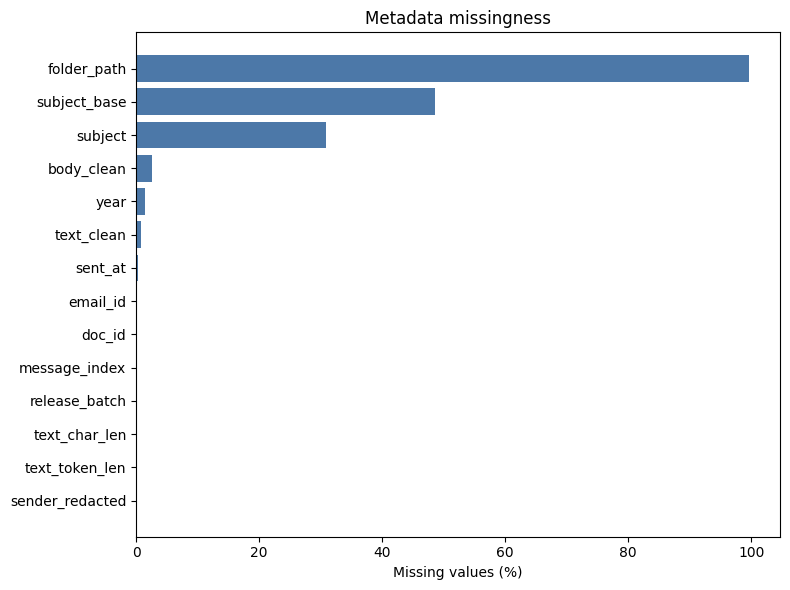

In [4]:

summary_rows = [
    ("raw_documents", f"{emails.height}"),
    ("analysis_documents", f"{analysis_emails.height}"),
    ("sampled_analysis_documents", f"{sampled_analysis_emails.height}"),
    ("average_document_tokens", f"{float(emails.get_column('text_token_len').mean()):.2f}"),
    ("median_document_tokens", f"{float(emails.get_column('text_token_len').median()):.0f}"),
    ("average_document_characters", f"{float(emails.get_column('text_char_len').mean()):.2f}"),
    ("median_document_characters", f"{float(emails.get_column('text_char_len').median()):.0f}"),
    ("empty_text_rows", f"{emails.filter(pl.col('text_token_len') == 0).height}"),
    ("very_short_rows_under_10_tokens", f"{emails.filter(pl.col('text_token_len') < 10).height}"),
    ("sender_redacted_rows", f"{emails.filter(pl.col('sender_redacted')).height}"),
    ("raw_min_sent_at", f"{emails.get_column('sent_at').min()}"),
    ("raw_max_sent_at", f"{emails.get_column('sent_at').max()}"),
    ("valid_dated_rows_1990_2019", f"{valid_dated_emails.height}"),
    ("missing_or_out_of_range_date_rows", f"{emails.height - valid_dated_emails.height}"),
    ("min_valid_sent_at", f"{valid_dated_emails.get_column('sent_at').min()}"),
    ("max_valid_sent_at", f"{valid_dated_emails.get_column('sent_at').max()}"),
    ("distinct_valid_years", f"{valid_dated_emails.get_column('year').n_unique()}"),
    ("people_rows", f"{people.height}"),
    ("email_person_links", f"{bridge.height}"),
]
write_frame(pl.DataFrame(summary_rows, schema=["metric", "value"], orient="row"), "corpus_summary.csv")

missing_exprs = []
for column in emails.columns:
    expr = pl.col(column).is_null()
    if emails.schema[column] == pl.String:
        expr = expr | (pl.col(column).str.strip_chars() == "")
    missing_exprs.append(expr.mean().alias(column))
missingness = (
    emails.select(missing_exprs)
    .transpose(include_header=True, header_name="field", column_names=["missing_rate"])
    .with_columns((pl.col("missing_rate") * 100).round(2).alias("missing_pct"))
    .sort("missing_rate", descending=True)
)
write_frame(missingness, "metadata_missingness.csv")

display(pl.DataFrame(summary_rows, schema=["metric", "value"], orient="row"))
display(missingness)

missing_plot = missingness.sort("missing_rate")
plt.figure(figsize=(8, 6))
plt.barh(missing_plot["field"].to_list(), missing_plot["missing_pct"].to_list(), color="#4c78a8")
plt.xlabel("Missing values (%)")
plt.title("Metadata missingness")
plt.tight_layout()
plt.savefig(Path("outputs") / "metadata_missingness.png", dpi=160)
plt.show()


## Date anomalies and time span

In [5]:
date_anomalies = (
    emails.filter(pl.col("sent_at").is_not_null() & pl.col("year").is_null())
    .select("email_id", "doc_id", "subject", "sent_at", "release_batch", "folder_path", "text_token_len")
    .sort("sent_at")
)
missing_sent_at_rows = emails.filter(pl.col("sent_at").is_null()).height
write_frame(
    pl.DataFrame(
        [
            ("missing_sent_at_rows", f"{missing_sent_at_rows}"),
            ("parsed_but_out_of_range_year_rows", f"{date_anomalies.height}"),
            ("missing_or_out_of_range_date_rows", f"{missing_sent_at_rows + date_anomalies.height}"),
            ("earliest_raw_sent_at", f"{emails.get_column('sent_at').min()}"),
            ("latest_raw_sent_at", f"{emails.get_column('sent_at').max()}"),
        ],
        schema=["metric", "value"],
        orient="row",
    ),
    "date_anomaly_summary.csv",
)
write_frame(date_anomalies.head(1000), "date_anomalies_sample.csv")

by_year = emails.group_by("year").agg(pl.len().alias("documents")).sort("year")
release_batch_coverage = emails.group_by("release_batch").agg(pl.len().alias("documents")).sort("release_batch")
write_frame(by_year, "documents_by_year.csv")
write_frame(release_batch_coverage, "release_batch_coverage.csv")
log("corpus metadata")

display(by_year)
display(release_batch_coverage)

[analysis] wrote outputs/date_anomaly_summary.csv
[analysis] wrote outputs/date_anomalies_sample.csv
[analysis] wrote outputs/documents_by_year.csv
[analysis] wrote outputs/release_batch_coverage.csv
[analysis] corpus metadata: phase=1.56s total=10.28s


year,documents
i32,u32
null,26266
1990,621
1991,1502
1992,2
1993,3
…,…
2015,170910
2016,166036
2017,199060


release_batch,documents
i64,u32
1,13864
2,20
3,12
4,12
5,1
8,1057
9,629550
10,447162
11,666633


## Language detection, readability, and KWIC

Controlled document loop over the sampled analysis set. Term frequencies, n-grams, and TF-IDF are handled by sklearn vectorizers in the next section.

In [6]:
readability_rows = []
language_counter = Counter()
language_confidence = Counter()
language_model = load_language_model()
language_batch = []
kwic_rows = {term: [] for term in ["island", "flight", "passport", "massage", "Maxwell"]}
kwic_patterns = {term: re.compile(re.escape(term), re.IGNORECASE) for term in kwic_rows}
doc_count = sampled_analysis_emails.height
analysis_texts = sampled_analysis_emails.get_column("text_clean").fill_null("").to_list()

for index, row in enumerate(
    sampled_analysis_emails.select("email_id", "sent_at", "subject", "text_clean").iter_rows(named=True),
    start=1,
):
    text = row["text_clean"] or ""
    tokens = tokenize(text)
    language_text = compact_language_text(text)
    if len(language_text) < 80:
        language_counter["too_short"] += 1
    elif language_model is None:
        language_counter[fallback_language_indicator(text)] += 1
    else:
        language_batch.append(language_text[:1000])
        if len(language_batch) >= 4096:
            flush_language_batch(language_model, language_batch, language_counter, language_confidence)
    if len(tokens) >= 50:
        metrics = text_metrics(text)
        if metrics:
            readability_rows.append(metrics)
    for term, pattern in kwic_patterns.items():
        if len(kwic_rows[term]) >= 500:
            continue
        for match in pattern.finditer(text):
            kwic_rows[term].append(
                {
                    "email_id": row["email_id"],
                    "sent_at": row["sent_at"],
                    "subject": row["subject"],
                    "left": text[max(0, match.start() - 80) : match.start()].replace("\n", " "),
                    "keyword": text[match.start() : match.end()],
                    "right": text[match.end() : match.end() + 80].replace("\n", " "),
                }
            )
            if len(kwic_rows[term]) >= 500:
                break
    if index % 100_000 == 0:
        print(f"[analysis] scanned {index:,}", flush=True)

if language_model is not None:
    flush_language_batch(language_model, language_batch, language_counter, language_confidence)
log("language indicators, readability, kwic")


[analysis] scanned 100,000
[analysis] scanned 200,000
[analysis] scanned 300,000
[analysis] scanned 400,000
[analysis] scanned 500,000
[analysis] scanned 600,000
[analysis] scanned 700,000
[analysis] scanned 800,000
[analysis] scanned 900,000
[analysis] scanned 1,000,000
[analysis] scanned 1,100,000
[analysis] scanned 1,200,000
[analysis] scanned 1,300,000
[analysis] scanned 1,400,000
[analysis] scanned 1,500,000
[analysis] scanned 1,600,000
[analysis] scanned 1,700,000
[analysis] language indicators, readability, kwic: phase=205.22s total=215.50s


## Language distribution

In [7]:
language_distribution = (
    pl.DataFrame(
        [
            (
                language,
                documents,
                None if language_confidence[language] == 0 else round(language_confidence[language] / documents, 4),
            )
            for language, documents in language_counter.items()
        ],
        schema=["language", "documents", "avg_confidence"],
        orient="row",
    )
    .with_columns((pl.col("documents") / pl.col("documents").sum() * 100).round(2).alias("pct"))
    .sort("documents", descending=True)
)
write_frame(language_distribution, "language_distribution.csv")
display(language_distribution)

[analysis] wrote outputs/language_distribution.csv


language,documents,avg_confidence,pct
str,i64,f64,f64
"""en""",952397,0.9191,54.65
"""too_short""",781310,null,44.83
"""fr""",2532,0.6871,0.15
"""de""",1401,0.5352,0.08
"""he""",1210,0.6471,0.07
…,…,…,…
"""kw""",1,0.1075,0.0
"""hi""",1,0.2435,0.0
"""diq""",1,0.0921,0.0


## Term and n-gram frequencies

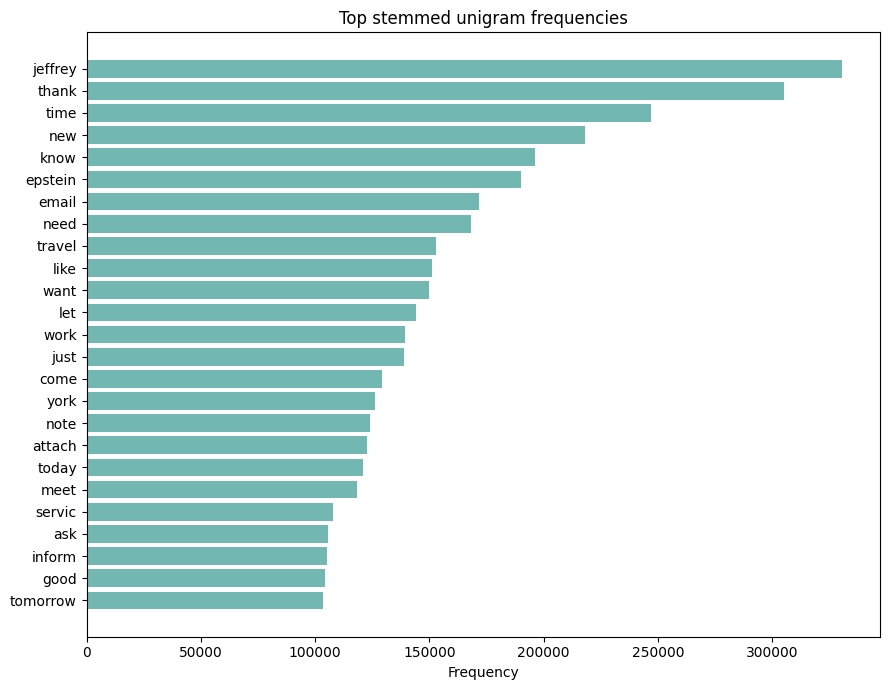

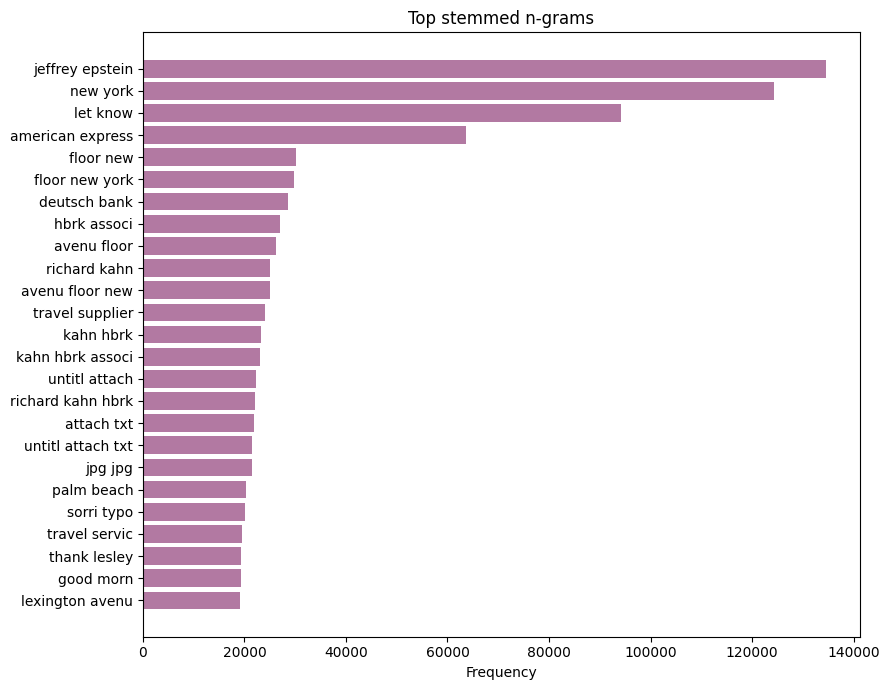

[analysis] sklearn count vectorizers: phase=196.43s total=411.93s


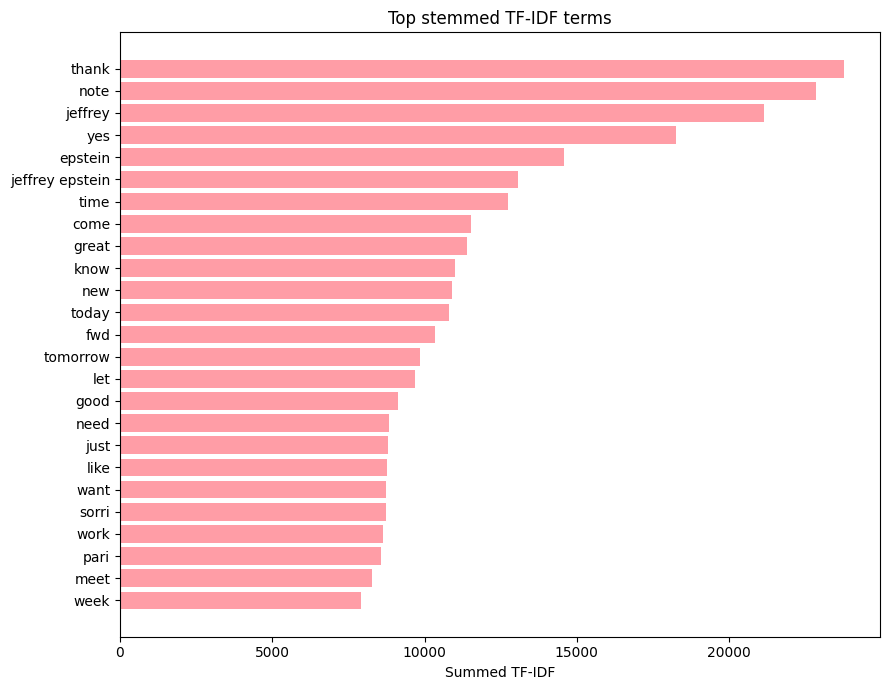

[analysis] sklearn tf-idf: phase=160.26s total=572.19s


In [8]:
def vectorizer_table(matrix, feature_names, label):
    freqs = matrix.sum(axis=0).A1
    doc_freqs = matrix.getnnz(axis=0)
    return pl.DataFrame(
        {
            label: feature_names,
            "frequency": freqs,
            "document_frequency": doc_freqs,
            "document_frequency_pct": doc_freqs / doc_count * 100,
        }
    ).sort("frequency", descending=True)


term_vectorizer = CountVectorizer(
    analyzer="word",
    tokenizer=tokenize,
    token_pattern=None,
    lowercase=False,
    min_df=vectorizer_min_df,
    max_df=vectorizer_max_df,
    ngram_range=(1, 1),
    max_features=vectorizer_max_features,
    dtype=np.int32,
)
term_matrix = term_vectorizer.fit_transform(analysis_texts)
term_frequency_table = vectorizer_table(term_matrix, term_vectorizer.get_feature_names_out(), "term")
term_frequency_table.head(100_000).write_csv(Path("outputs") / "term_frequencies.csv")
top_terms = term_frequency_table.head(25).reverse()
plot_barh(top_terms["term"], top_terms["frequency"], "top_terms.png", "Top stemmed unigram frequencies", "Frequency", "#72b7b2")

ngram_vectorizer = CountVectorizer(
    analyzer="word",
    tokenizer=tokenize,
    token_pattern=None,
    lowercase=False,
    min_df=vectorizer_min_df,
    max_df=vectorizer_max_df,
    ngram_range=(2, vectorizer_ngram_range[1]),
    max_features=vectorizer_max_features,
    dtype=np.int32,
)
ngram_matrix = ngram_vectorizer.fit_transform(analysis_texts)
ngram_table = vectorizer_table(ngram_matrix, ngram_vectorizer.get_feature_names_out(), "ngram")
ngram_table.head(100_000).write_csv(Path("outputs") / "ngrams.csv")
top_ngrams = ngram_table.head(25).reverse()
plot_barh(top_ngrams["ngram"], top_ngrams["frequency"], "top_ngrams.png", "Top stemmed n-grams", "Frequency", "#b279a2")
log("sklearn count vectorizers")

tfidf_vectorizer = TfidfVectorizer(
    analyzer="word",
    tokenizer=tokenize,
    token_pattern=None,
    lowercase=False,
    min_df=vectorizer_min_df,
    max_df=vectorizer_max_df,
    ngram_range=vectorizer_ngram_range,
    max_features=vectorizer_max_features,
    dtype=np.float32,
)
tfidf_matrix = tfidf_vectorizer.fit_transform(analysis_texts)
tfidf_table = pl.DataFrame(
    {
        "term": tfidf_vectorizer.get_feature_names_out(),
        "tfidf_keyness": tfidf_matrix.sum(axis=0).A1,
        "document_frequency": tfidf_matrix.getnnz(axis=0),
    }
).with_columns(
    (pl.col("document_frequency") / doc_count * 100).alias("document_frequency_pct")
).sort("tfidf_keyness", descending=True)
tfidf_table.head(100_000).write_csv(Path("outputs") / "tfidf_key_terms.csv")
top_tfidf = tfidf_table.head(25).reverse()
plot_barh(top_tfidf["term"], top_tfidf["tfidf_keyness"], "top_tfidf_terms.png", "Top stemmed TF-IDF terms", "Summed TF-IDF", "#ff9da6")
log("sklearn tf-idf")


## KWIC concordances

In [9]:
for term, rows in kwic_rows.items():
    pl.DataFrame(rows).write_csv(Path("outputs") / f"kwic_{term.lower()}.csv")
    print(f"kwic_{term.lower()}: {len(rows)} rows")
log("kwic")

kwic_island: 500 rows
kwic_flight: 500 rows
kwic_passport: 500 rows
kwic_massage: 500 rows
kwic_maxwell: 500 rows
[analysis] kwic: phase=0.04s total=572.23s


## Readability and lexical diversity

statistic,tokens,sentences,types,type_token_ratio,flesch_reading_ease,flesch_kincaid_grade
str,f64,f64,f64,f64,f64,f64
"""count""",114791.0,114791.0,114791.0,114791.0,114791.0,114791.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",226.227622,18.977951,131.181086,0.673316,48.027764,9.951334
"""std""",420.718295,30.241466,152.333138,0.12147,21.300754,5.145382
"""min""",50.0,1.0,1.0,0.004545,-535.404831,-3.404105
"""25%""",94.0,8.0,69.0,0.60355,35.784605,7.026721
"""50%""",127.0,12.0,89.0,0.688073,50.355345,9.1842
"""75%""",214.0,21.0,136.0,0.757576,62.788459,11.743098
"""max""",19844.0,1636.0,4811.0,1.0,121.230684,234.51


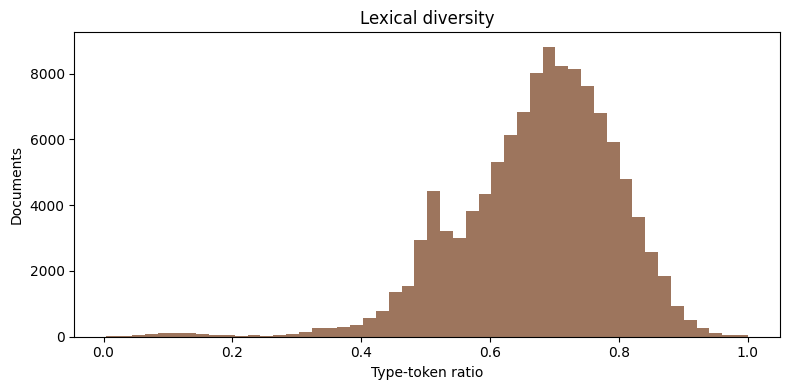

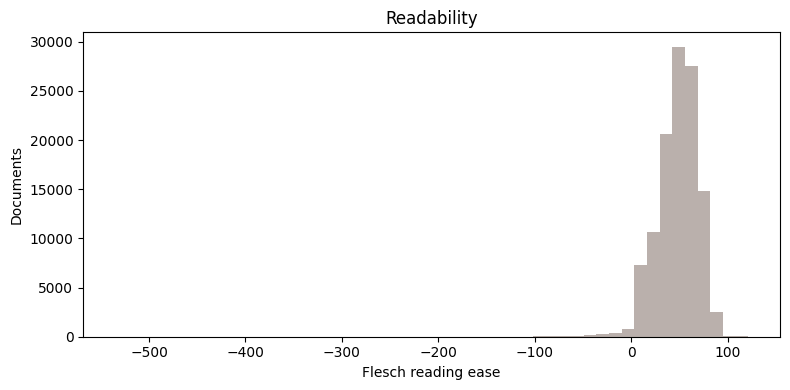

[analysis] readability: phase=1.82s total=574.05s


In [10]:
readability_table = pl.DataFrame(readability_rows)
readability_summary = readability_table.describe()
display(readability_summary)
readability_summary.write_csv(Path("outputs") / "readability_lexical_summary.csv")
readability_table.sample(n=min(100_000, readability_table.height), seed=7).write_csv(
    Path("outputs") / "readability_lexical_sample.csv"
)

plt.figure(figsize=(8, 4))
plt.hist(readability_table["type_token_ratio"].to_list(), bins=50, color="#9d755d")
plt.xlabel("Type-token ratio")
plt.ylabel("Documents")
plt.title("Lexical diversity")
plt.tight_layout()
plt.savefig(Path("outputs") / "lexical_diversity.png", dpi=160)
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(readability_table["flesch_reading_ease"].to_list(), bins=50, color="#bab0ac")
plt.xlabel("Flesch reading ease")
plt.ylabel("Documents")
plt.title("Readability")
plt.tight_layout()
plt.savefig(Path("outputs") / "readability.png", dpi=160)
plt.show()
log("readability")

## People network

In [ ]:
top_people = (
    bridge.group_by("person_id", "person_name")
    .agg(pl.col("email_id").n_unique().alias("documents"), pl.len().alias("links"))
    .sort("documents", descending=True)
    .head(100)
)
role_counts = (
    bridge.group_by("involvement_role")
    .agg(pl.len().alias("links"), pl.col("email_id").n_unique().alias("documents"))
    .sort("links", descending=True)
)
linked_document_count = bridge.select(pl.col("email_id").n_unique()).item()
people_coverage = pl.DataFrame(
    [
        ("documents_with_people", f"{linked_document_count}"),
        ("analysis_documents", f"{analysis_emails.height}"),
        ("documents_with_people_pct", f"{linked_document_count / analysis_emails.height * 100:.2f}"),
    ],
    schema=["metric", "value"],
    orient="row",
)
write_frame(top_people, "top_people.csv")
write_frame(role_counts, "involvement_role_counts.csv")
write_frame(people_coverage, "people_coverage.csv")

display(people_coverage)
display(role_counts)

top_people_plot = top_people.head(25).reverse()
plot_barh(top_people_plot["person_name"], top_people_plot["documents"], "top_people.png", "Top linked people", "Linked documents", "#59a14f")
log("people")

[analysis] wrote outputs/top_people.csv
[analysis] wrote outputs/involvement_role_counts.csv
[analysis] wrote outputs/people_coverage.csv


metric,value
str,str
"""documents_with_people""","""1540082"""
"""analysis_documents""","""1742760"""
"""documents_with_people_pct""","""88.37"""


## Run metadata

In [ ]:
metadata = {
    "documents_available": analysis_emails.height,
    "documents_processed": doc_count,
    "sample_documents": sample_documents,
    "sample_seed": sample_seed,
    "use_stemming": use_stemming,
    "vectorizer_min_df": vectorizer_min_df,
    "vectorizer_max_df": vectorizer_max_df,
    "vectorizer_ngram_range": vectorizer_ngram_range,
    "vectorizer_max_features": vectorizer_max_features,
    "term_vectorizer_rows": len(term_frequency_table),
    "ngram_vectorizer_rows": len(ngram_table),
    "tfidf_vectorizer_rows": len(tfidf_table),
    "keyness_method": "sklearn TfidfVectorizer with summed document TF-IDF scores over the sampled analysis set",
    "language_detection": "fastText lid.176.ftz when fasttext is installed; fallback buckets otherwise",
    "runtime_seconds": round(perf_counter() - started_at, 2),
}
(Path("outputs") / "run_metadata.json").write_text(json.dumps(metadata, indent=2) + "\n")
print(json.dumps(metadata, indent=2))
